In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# %matplotlib inline  # works in notebooks; ignored in scripts
import warnings

warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold
import lightgbm as lgbm
from sklearn.metrics import mean_squared_error
from pathlib import Path


# Resolve data paths (Kaggle, local, or working directory)
def get_path(*parts):
    possible_roots = [
        Path("/kaggle/input/petfinder-pawpularity-score"),  # typical Kaggle path
        Path("../input/petfinder-pawpularity-score"),  # relative from repo
        Path("data/petfinder-pawpularity-score"),  # fallback used in description
        Path("."),
    ]
    for root in possible_roots:
        p = root.joinpath(*parts)
        if p.exists():
            return p
    raise FileNotFoundError(f"Unable to locate {'/'.join(parts)}")


train_path = get_path("train.csv")
test_path = get_path("test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)




In [2]:
train.head()




,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48


In [3]:
# Correlation only on numeric columns (exclude Id which is a string)
numeric_train = train.select_dtypes(include=[np.number])
train_corr = numeric_train.corr()
train_corr




,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
Subject Focus,1.000000,0.079214,0.040622,0.057534,0.004414,0.029099,-0.050071,-0.038301,-0.074608,-0.076355,-0.039947,-0.046172,-0.012742
Eyes,0.079214,1.000000,0.584935,0.130222,-0.019711,0.051978,-0.084850,0.069939,0.037358,0.020617,0.040636,-0.508955,-0.016055
Face,0.040622,0.584935,1.000000,0.139080,-0.010138,0.034800,-0.106588,0.053745,0.025983,0.010077,0.024962,-0.062600,0.002306
Near,0.057534,0.130222,0.139080,1.000000,-0.019203,0.031132,-0.319996,-0.260031,0.064987,-0.006104,-0.143234,-0.011080,0.000390
Action,0.004414,-0.019711,-0.010138,-0.019203,1.000000,0.027867,-0.007605,-0.001734,-0.010506,-0.015076,-0.015890,0.017110,-0.005092
Accessory,0.029099,0.051978,0.034800,0.031132,0.027867,1.000000,-0.056962,0.067880,-0.038230,-0.032814,0.074471,-0.032394,0.010911
Group,-0.050071,-0.084850,-0.106588,-0.319996,-0.007605,-0.056962,1.000000,0.133201,-0.104275,0.003098,0.064354,0.005877,0.020392
Collage,-0.038301,0.069939,0.053745,-0.260031,-0.001734,0.067880,0.133201,1.000000,0.014389,0.055274,0.480268,-0.035000,0.004594
Human,-0.074608,0.037358,0.025983,0.064987,-0.010506,-0.038230,-0.104275,0.014389,1.000000,0.633096,0.021514,-0.018370,0.001640
Occlusion,-0.076355,0.020617,0.010077,-0.006104,-0.015076,-0.032814,0.003098,0.055274,0.633096,1.000000,0.120626,-0.007789,-0.000418


<Axes: >

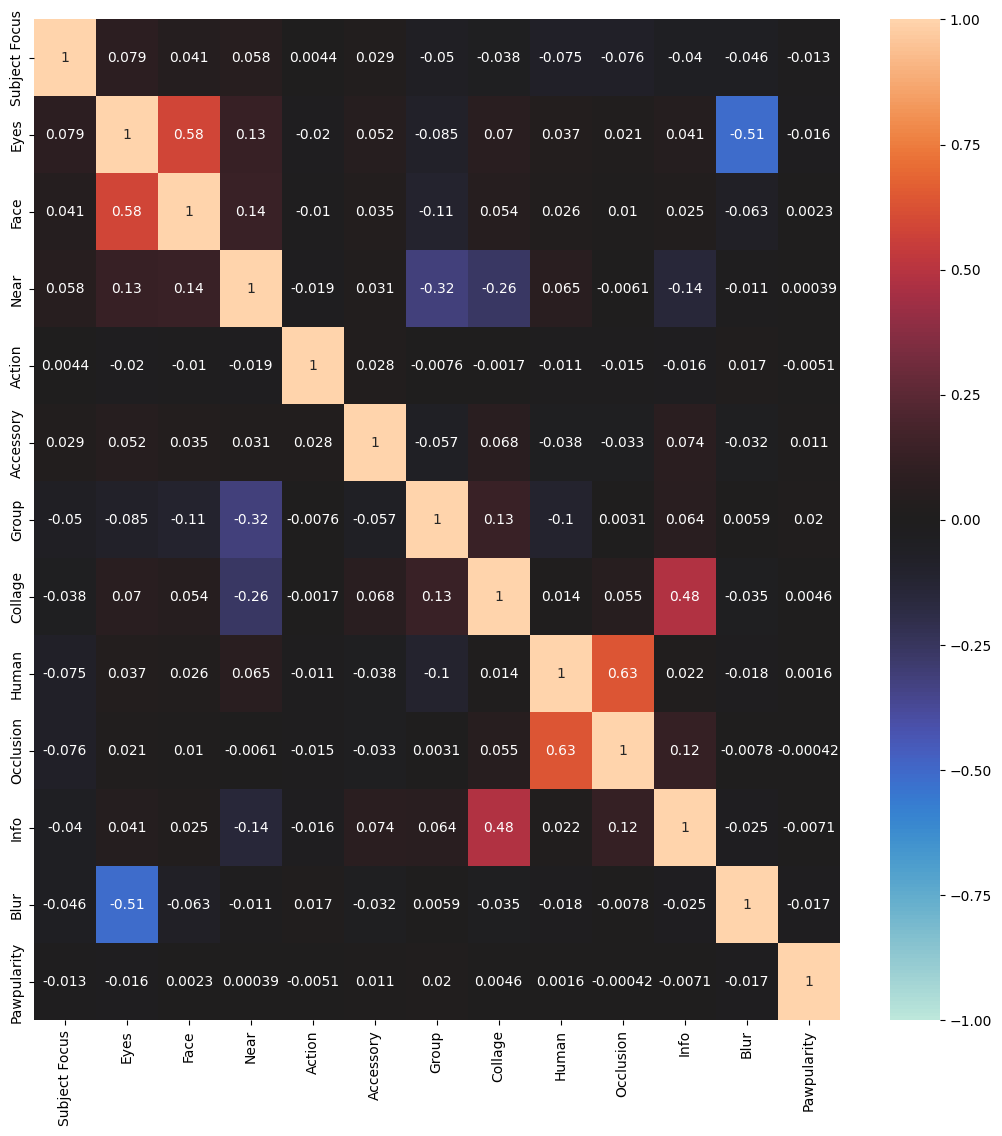

In [4]:
plt.figure(figsize=(13, 13))
sns.heatmap(train_corr, vmax=1, vmin=-1, center=0, annot=True)




<Axes: ylabel='Frequency'>

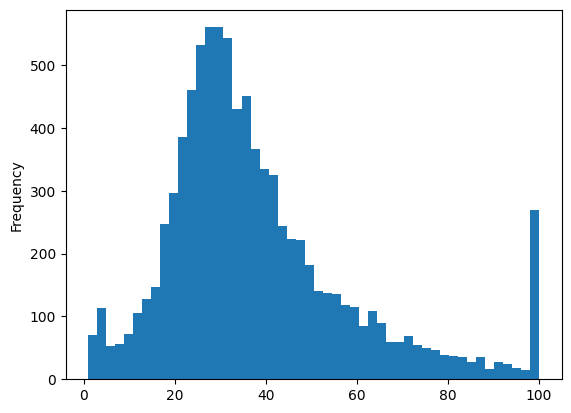

In [5]:
train["Pawpularity"].plot.hist(bins=50)




In [6]:
# Convert Id to categorical for LightGBM handling
train["Id"] = train["Id"].astype("category")
test["Id"] = test["Id"].astype("category")

X_train = train.drop(["Pawpularity"], axis=1)
Y_train = train["Pawpularity"]




In [7]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
models = []
rmses = []
categories = ["Id"]

lgbm_params = {
    "objective": "regression",
    "metric": "rmse",
    "random_seed": 1234,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
}

for train_index, val_index in kf.split(X_train):
    XX_train = X_train.iloc[train_index]
    XX_valid = X_train.iloc[val_index]
    YY_train = Y_train.iloc[train_index]
    YY_valid = Y_train.iloc[val_index]

    lgbm_train = lgbm.Dataset(XX_train, YY_train, categorical_feature=categories)
    lgbm_valid = lgbm.Dataset(
        XX_valid, YY_valid, categorical_feature=categories, reference=lgbm_train
    )

    model_lgbm = lgbm.train(
        lgbm_params,
        lgbm_train,
        num_boost_round=200,
        valid_sets=[lgbm_valid],
        # verbose_eval omitted – not supported in this version
    )

    y_pred = model_lgbm.predict(XX_valid, num_iteration=model_lgbm.best_iteration)
    tmp_rmse = np.sqrt(mean_squared_error(YY_valid, y_pred))
    print(tmp_rmse)

    models.append(model_lgbm)
    rmses.append(tmp_rmse)




20.98943405866397
20.941675477346692
20.403245313202685


In [8]:
average_rmse = sum(rmses) / len(rmses) if rmses else float("nan")
print("Average CV RMSE:", average_rmse)




Average CV RMSE: 20.77811828307112


In [9]:
test.head()




,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0


In [10]:
# Id already cast to category in cell 6




In [11]:
preds = []
for model in models:
    pred = model.predict(test, num_iteration=model.best_iteration)
    preds.append(pred)

preds_array = np.vstack(preds)  # shape: (n_models, n_samples)
preds_mean = preds_array.mean(axis=0)

# Clip predictions to the allowed range [0, 100] (Kaggle expects 1‑100, but 0 is safe)
preds_mean = np.clip(preds_mean, 0, 100)




In [12]:
sub = pd.DataFrame({"Id": test["Id"], "Pawpularity": preds_mean})
sub.to_csv("submission.csv", index=False)
print("Submission saved. Sample:")
print(sub.head())

Submission saved. Sample:
                                 Id  Pawpularity
0  ee51b99832f1ba868f646df93d2b6b81    37.943928
1  caddfb3f8bff9c4b95dbe022018eea21    43.676607
2  582eeabd4a448a53ebb79995888a4b0b    37.128798
3  afc1ad7f0c5eea880759d09e77f7deee    37.943928
4  d5bdf3446e86ce4ec67ce7a00f1cccc2    30.984797
